<div style="background: linear-gradient(135deg, #1F4E79 0%, #2E75B6 50%, #00B4D8 100%); padding: 40px 30px; border-radius: 16px; margin-bottom: 10px;">

<h1 style="color: white; font-size: 2.2em; font-weight: 900; text-align: center; margin: 0 0 6px 0; letter-spacing: 1px;">
🔐 Predicting Cybersecurity Vulnerability Severity
</h1>

<h3 style="color: #BDE3FF; font-size: 1.15em; text-align: center; margin: 0 0 20px 0; font-weight: 400;">
A Supervised Machine Learning Regression Study on the National Vulnerability Database (NVD)
</h3>

<hr style="border: 1px solid rgba(255,255,255,0.3); margin: 16px 0;">

<table style="width:100%; color:white; font-size:0.95em; border-collapse:collapse;">
<tr>
<td style="width:50%; padding:6px 10px;">📁 <b>Dataset</b> &nbsp; NVD_Cybersecurity_Dataset.csv</td>
<td style="width:50%; padding:6px 10px;">📊 <b>Records</b> &nbsp; 337,705 CVEs × 19 Features</td>
</tr>
<tr>
<td style="padding:6px 10px;">🎯 <b>Target</b> &nbsp; CVSS Base Score (0.0 – 10.0)</td>
<td style="padding:6px 10px;">✂️ <b>Split</b> &nbsp; 80% Training / 20% Testing</td>
</tr>
<tr>
<td style="padding:6px 10px;">📅 <b>Coverage</b> &nbsp; 1988 – 2026 (38 Years)</td>
<td style="padding:6px 10px;">🔁 <b>Validation</b> &nbsp; 5-Fold Cross-Validation</td>
</tr>
</table>

<hr style="border: 1px solid rgba(255,255,255,0.3); margin: 16px 0;">

<div style="display:flex; gap:10px; flex-wrap:wrap; justify-content:center;">
<span style="background:rgba(255,255,255,0.18); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">🔍 Pearson Correlation</span>
<span style="background:rgba(255,255,255,0.18); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">📡 Mutual Information</span>
<span style="background:rgba(255,255,255,0.18); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">📐 Chi-Square Test</span>
<span style="background:rgba(255,255,255,0.18); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">📈 F-Regression</span>
<span style="background:rgba(255,255,255,0.18); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">🔄 RFE</span>
<span style="background:rgba(255,255,255,0.18); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">🌲 RF Importance</span>
</div>

<div style="display:flex; gap:10px; flex-wrap:wrap; justify-content:center; margin-top:8px;">
<span style="background:rgba(232,93,4,0.7); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">📏 Linear Regression</span>
<span style="background:rgba(232,93,4,0.7); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">🌿 Decision Tree</span>
<span style="background:rgba(27,67,50,0.8); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">🌳 Random Forest</span>
<span style="background:rgba(90,24,154,0.7); color:white; padding:5px 14px; border-radius:20px; font-size:0.85em;">🚀 Gradient Boosting</span>
</div>

</div>

<div style="background:#FFF8E1; border-left:5px solid #E85D04; padding:12px 18px; border-radius:6px; margin-top:12px;">
<b>📌 Assignment Note:</b> Run each cell from top to bottom in order. Upload <code>NVD_Cybersecurity_Dataset.csv</code> to your Colab session before running Cell 3.
</div>

---
## 📦 Cell 1 — Install Required Libraries

Before we do anything, we need to make sure all the Python packages we need are installed.

Google Colab already has most of these (like `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`), but we run this cell anyway to be safe. `joblib` is used later to **save our trained models** to disk so we can load them again without retraining.

> **What each library does:**
> - `pandas` — loads and manipulates the CSV dataset (like Excel in Python)
> - `numpy` — fast number crunching (arrays, maths)
> - `matplotlib` + `seaborn` — drawing all our charts and graphs
> - `scikit-learn` — all the machine learning algorithms and feature selection tools
> - `joblib` — saves trained models to `.pkl` files so we don't have to retrain them every time

In [1]:
# install any packages that might be missing in this Colab environment
# most of these come pre-installed, but it's good practice to be explicit
!pip install pandas numpy matplotlib seaborn scikit-learn joblib --quiet

print("All libraries ready!")

All libraries ready!


---
## 🗂️ Cell 2 — Import Libraries & Set Up Configuration

Now we import everything into our Python session and define all the settings we'll use throughout the notebook.

Keeping the configuration in one place (like `DATASET_PATH`, `TEST_SIZE`, `RANDOM_STATE`) is good practice — it means if you want to change something (e.g. try a different train/test split), you only change it in **one place** and the whole notebook updates automatically.

> **Key settings explained:**
> - `TEST_SIZE = 0.20` → 20% of data goes to testing, 80% to training
> - `RANDOM_STATE = 42` → fixes the random seed so results are the same every run
> - `CV_FOLDS = 5` → we validate each model across 5 different data splits
> - `SHOW_PLOTS = True` → charts display inline inside the notebook
> - The colour palette is set here so all charts have a consistent look throughout

In [2]:
import os, time, json, warnings, datetime

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn           as sns
import joblib

from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression, RFE, f_regression, chi2
from sklearn.preprocessing   import MinMaxScaler

warnings.filterwarnings("ignore")

# ── where to find / save things ────────────────────────────────────────────
DATASET_PATH = "NVD_Cybersecurity_Dataset.csv"   # CSV must be uploaded to Colab
OUTPUT_DIR   = "output_figures"                   # all charts go here
MODELS_DIR   = "saved_models"                     # trained model files go here

# create these folders if they don't exist yet
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# ── experiment settings ────────────────────────────────────────────────────
RANDOM_STATE = 42      # fixed seed so results are reproducible every run
TEST_SIZE    = 0.20    # 80% train, 20% test
CV_FOLDS     = 5       # number of folds for cross-validation
CV_SAMPLE    = 80_000  # CV on this many training records (keeps runtime manageable)
SHOW_PLOTS   = True    # True = charts show inline in the notebook

# ── colour palette (used across every chart for a consistent look) ─────────
DARK   = "#1F4E79"   # dark navy
MID    = "#2E75B6"   # mid blue  — Linear Regression
ORANGE = "#E85D04"   # orange    — Decision Tree
GREEN  = "#2D6A4F"   # dark green — Random Forest
PURPLE = "#5A189A"   # purple    — Gradient Boosting
RED    = "#D62828"   # red       — perfect-prediction lines / warnings
BG     = "#F0F4F8"   # light grey background for chart panels

# one colour per model — same order used in every chart
MODEL_COLORS = [MID, ORANGE, GREEN, PURPLE]

# ── global matplotlib style ────────────────────────────────────────────────
plt.rcParams.update({
    "font.family"       : "DejaVu Sans",
    "axes.facecolor"    : BG,
    "figure.facecolor"  : "white",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
    "figure.dpi"        : 100,
})

# ── the 13 input features we will use to predict CVSS score ───────────────
TARGET = "CVSS_Base_Score"

FEATURES = [
    "Exploitability_Score",      # how easy it is to exploit this vulnerability
    "Impact_Score",              # how bad the impact is if exploited — dominant predictor
    "Word_Count",                # how many words are in the CVE description
    "Char_Length",               # how many characters are in the description
    "Publish_Year",              # year the CVE was published
    "Publish_Month",             # month the CVE was published
    "Flag_XSS",                  # 1 if description mentions Cross-Site Scripting
    "Flag_SQLi",                 # 1 if description mentions SQL Injection
    "Flag_Buffer_Overflow",      # 1 if description mentions Buffer Overflow
    "Flag_RCE",                  # 1 if description mentions Remote Code Execution
    "Flag_Privilege_Escalation", # 1 if description mentions Privilege Escalation
    "Flag_DoS",                  # 1 if description mentions Denial of Service
    "Flag_Directory_Traversal",  # 1 if description mentions Directory Traversal
]

# shorter names for chart axis labels so they don't overlap
SHORT = [
    "Exploit.Score", "Impact_Score", "Word_Count", "Char_Length",
    "Pub_Year", "Pub_Month", "Flag_XSS", "Flag_SQLi",
    "Flag_Buf_Ovfl", "Flag_RCE", "Flag_PrivEsc", "Flag_DoS", "Flag_DirTrav",
]

print("Configuration done!")
print(f"  Dataset : {DATASET_PATH}")
print(f"  Split   : {int((1-TEST_SIZE)*100)}% Train / {int(TEST_SIZE*100)}% Test")
print(f"  Seed    : {RANDOM_STATE}")
print(f"  Folders : {OUTPUT_DIR}/  and  {MODELS_DIR}/")

Configuration done!
  Dataset : NVD_Cybersecurity_Dataset.csv
  Split   : 80% Train / 20% Test
  Seed    : 42
  Folders : output_figures/  and  saved_models/


---
## 📂 Cell 3 — Upload Dataset & Load Data

**Before running this cell**, you need to upload your dataset file to Colab:
1. Click the **folder icon** on the left sidebar in Colab
2. Click the **upload button** (page with an up-arrow)
3. Select `NVD_Cybersecurity_Dataset.csv` from your computer
4. Wait for the upload to complete, then run this cell

This cell loads the entire CSV into a pandas DataFrame and gives us a complete overview of the data — shape, column types, missing values, and basic statistics about our target variable (CVSS Base Score). Think of it like opening the spreadsheet and doing a first inspection before any analysis.

> **What we expect to see:**
> - 337,705 rows and 19 columns
> - Zero missing values (clean dataset)
> - CVSS scores ranging from 0.0 to 10.0 with a mean around 6.3

In [3]:
# quick helper to format seconds into a readable time string
def fmt_time(s):
    return f"{s:.1f}s" if s < 60 else f"{int(s//60)}m {int(s%60)}s"

# helper to save and optionally display a chart
def save_and_show(filename, dpi=150):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"  Saved → {path}")
    if SHOW_PLOTS:
        plt.show()   # this shows the chart inline in the notebook
    plt.close()

print("Loading dataset...")
t0 = time.time()

df = pd.read_csv(DATASET_PATH)

mem_mb = df.memory_usage(deep=True).sum() / 1_048_576
print(f"\n  File      : {DATASET_PATH}")
print(f"  Shape     : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"  Memory    : {mem_mb:.1f} MB")
print(f"  Load time : {fmt_time(time.time() - t0)}")

print("\n── Column types ──────────────────────────────────")
print(df.dtypes.to_string())

print("\n── Missing values ────────────────────────────────")
missing = df.isnull().sum()
# only print columns that actually have missing values
if missing.any():
    print(missing[missing > 0].to_string())
else:
    print("  None — dataset is 100% complete")

print("\n── First 5 rows (key columns) ────────────────────")
preview_cols = ["CVE_ID", "Publish_Year", TARGET, "Severity",
                "Exploitability_Score", "Impact_Score"]
print(df[preview_cols].head().to_string(index=False))

print(f"\n── Target variable: {TARGET} ─────────────────────")
print(df[TARGET].describe().round(3).to_string())

print("\n── Severity distribution ─────────────────────────")
for sev, count in df["Severity"].value_counts().items():
    print(f"   {sev:<12} {count:>7,}  ({count/len(df)*100:.1f}%)")

Loading dataset...

  File      : NVD_Cybersecurity_Dataset.csv
  Shape     : 337,705 rows  x  19 columns
  Memory    : 339.8 MB
  Load time : 7.9s

── Column types ──────────────────────────────────
CVE_ID                        object
Published_Date                object
Publish_Year                   int64
Publish_Month                  int64
Description                   object
Clean_Description             object
Word_Count                     int64
Char_Length                    int64
Flag_XSS                       int64
Flag_SQLi                      int64
Flag_Buffer_Overflow           int64
Flag_RCE                       int64
Flag_Privilege_Escalation      int64
Flag_DoS                       int64
Flag_Directory_Traversal       int64
CVSS_Base_Score              float64
Severity                      object
Exploitability_Score         float64
Impact_Score                 float64

── Missing values ────────────────────────────────
  None — dataset is 100% complete

── First 5

---
## 📊 Cell 4 — Exploratory Data Analysis (EDA): Part 1 of 2
### Figures 1, 2, 3 — Score Distribution, Severity Pie, CVEs Per Year

EDA means exploring the data visually before doing any machine learning. This is how data scientists "get to know" the dataset — understanding what the numbers look like, whether there are patterns, and whether there are any surprises.

**What these three charts show:**
- **Fig 1 (CVSS Distribution):** The shape of our target variable. We can see it's not a normal bell curve — it has two humps (bimodal), peaking around 5.0 and 7.5, which tells us most vulnerabilities are Medium or High severity.
- **Fig 2 (Severity Pie):** How many CVEs fall into each severity category. MEDIUM (44%) and HIGH (36.6%) together make up over 80% of the dataset.
- **Fig 3 (CVEs Per Year):** How many new CVEs were published each year. Notice the explosion after 2017 — this reflects growing security awareness and more vulnerabilities being discovered.

  Saved → output_figures/fig01_cvss_distribution.png


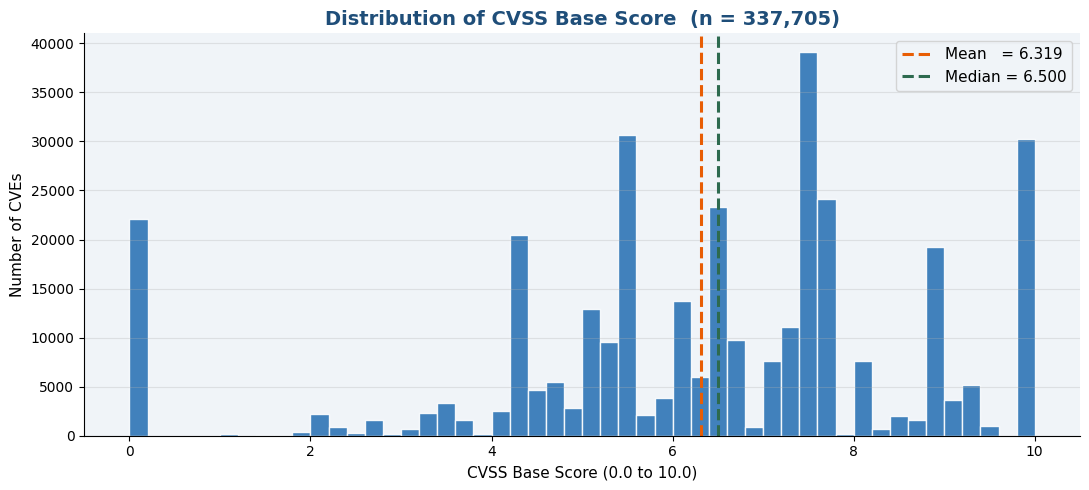

  Saved → output_figures/fig02_severity_pie.png


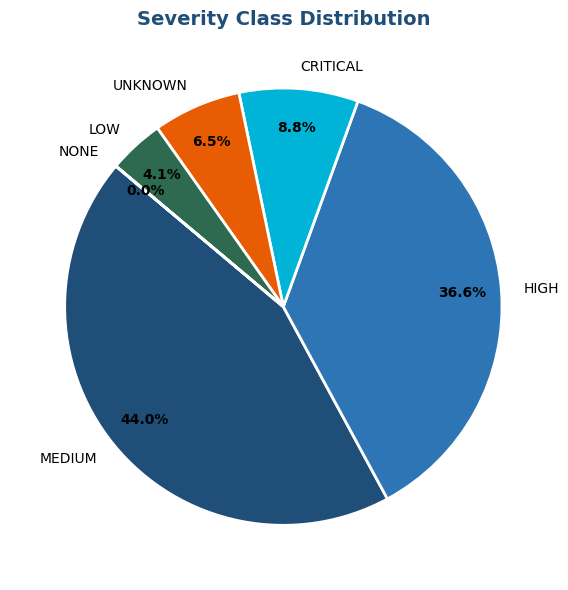

  Saved → output_figures/fig03_cves_per_year.png


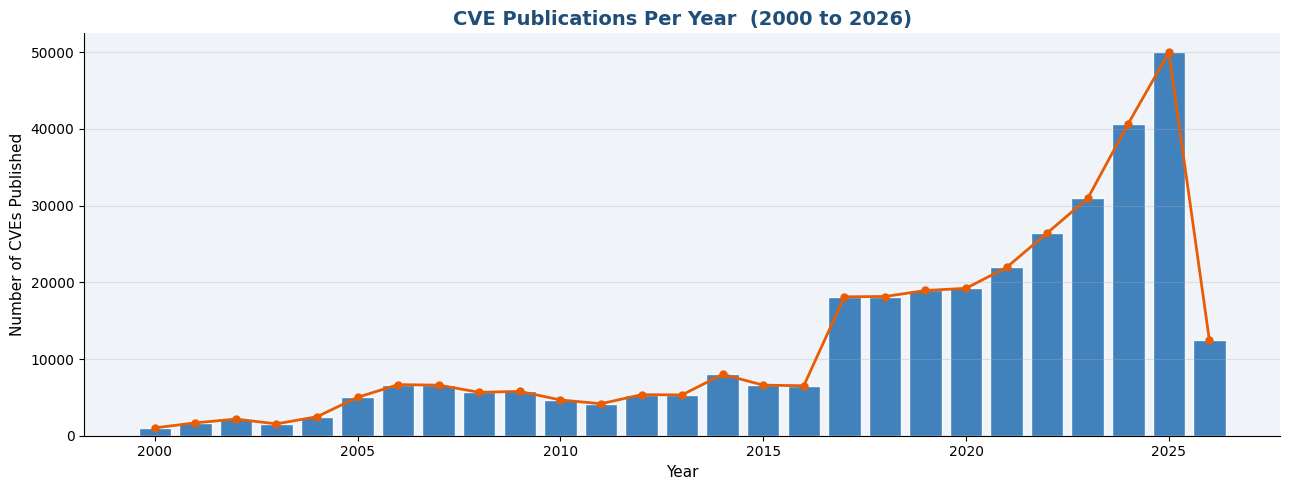

In [4]:
# ── Figure 1: Distribution of CVSS Base Score ──────────────────────────────
# this shows us what the target variable looks like across all 337,705 records
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(df[TARGET], bins=50, color=MID, edgecolor="white", alpha=0.9)

mean_v = df[TARGET].mean()
med_v  = df[TARGET].median()

# draw vertical lines for the mean and median so we can see where they sit
ax.axvline(mean_v, color=ORANGE, lw=2.2, linestyle="--", label=f"Mean   = {mean_v:.3f}")
ax.axvline(med_v,  color=GREEN,  lw=2.2, linestyle="--", label=f"Median = {med_v:.3f}")

ax.set_title(f"Distribution of CVSS Base Score  (n = {len(df):,})", color=DARK, fontsize=14)
ax.set_xlabel("CVSS Base Score (0.0 to 10.0)")
ax.set_ylabel("Number of CVEs")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_and_show("fig01_cvss_distribution.png")

# ── Figure 2: Severity Class Pie Chart ─────────────────────────────────────
# this shows us how the dataset is split across LOW / MEDIUM / HIGH / CRITICAL
sev_counts = df["Severity"].value_counts()
pie_colors = [DARK, MID, "#00B4D8", ORANGE, GREEN, RED]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sev_counts.values, labels=sev_counts.index,
    autopct="%1.1f%%", colors=pie_colors[:len(sev_counts)],
    startangle=140, pctdistance=0.82,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10); t.set_fontweight("bold")

ax.set_title("Severity Class Distribution", color=DARK, fontsize=14)
plt.tight_layout()
save_and_show("fig02_severity_pie.png")

# ── Figure 3: CVEs Published Per Year ──────────────────────────────────────
# only look at records from 2000 onwards — pre-2000 data is very sparse
yearly = df[df["Publish_Year"] >= 2000].groupby("Publish_Year").size()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(yearly.index, yearly.values, color=MID, edgecolor="white", alpha=0.9)
# add a line on top of the bars to make the trend easier to see
ax.plot(yearly.index, yearly.values, color=ORANGE, lw=2, marker="o", markersize=5)

ax.set_title("CVE Publications Per Year  (2000 to 2026)", color=DARK, fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of CVEs Published")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_and_show("fig03_cves_per_year.png")

---
## 📊 Cell 5 — Exploratory Data Analysis (EDA): Part 2 of 2
### Figures 4, 5, 6 — Attack Flags, Avg CVSS, Correlation Heatmap

**What these three charts show:**
- **Fig 4 (Attack Flags):** How often each attack type appears in the dataset. DoS is the most common, but RCE and Buffer Overflow tend to have the highest CVSS scores.
- **Fig 5 (Avg CVSS by Severity):** The average score within each severity category, with error bars (±1 standard deviation). The clean separation between LOW ≈ 2.5, MEDIUM ≈ 5.5, HIGH ≈ 7.3, CRITICAL ≈ 9.2 is a great sign that our target variable is meaningful.
- **Fig 6 (Correlation Heatmap):** Shows how strongly each feature is linearly related to every other feature. The darker the blue, the stronger the positive relationship. We can see `Impact_Score` has a very strong positive correlation with `CVSS_Base_Score` (r = 0.797).

> **Correlation heatmap tip:** We only show the lower triangle to avoid repeating every number twice.

  Saved → output_figures/fig04_attack_flags.png


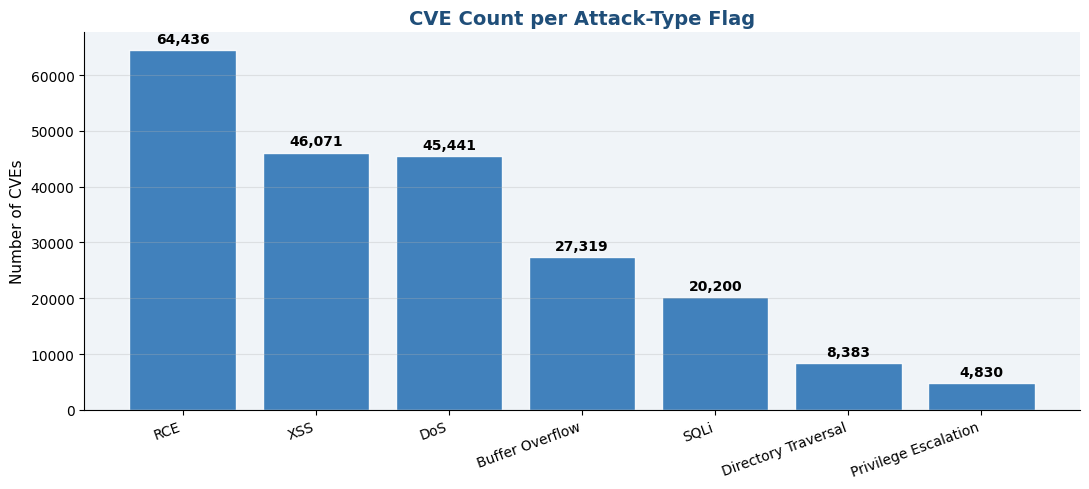

  Saved → output_figures/fig05_avg_cvss_severity.png


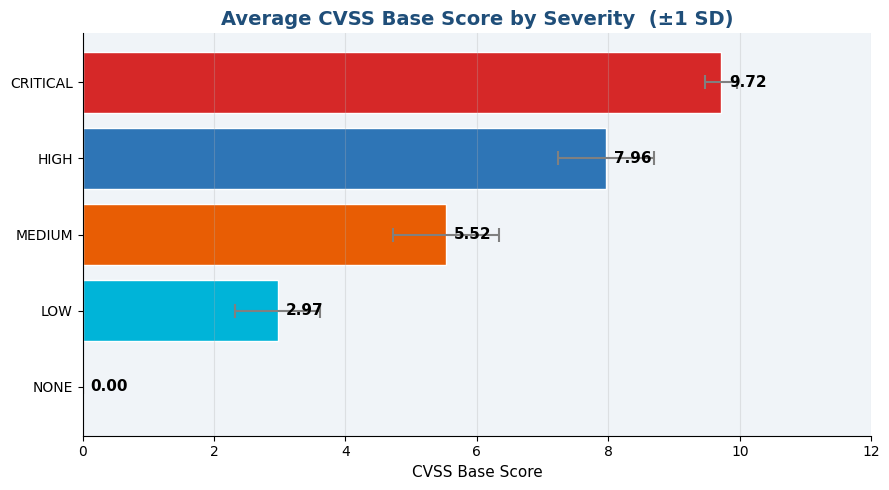

  Saved → output_figures/fig06_correlation_heatmap.png


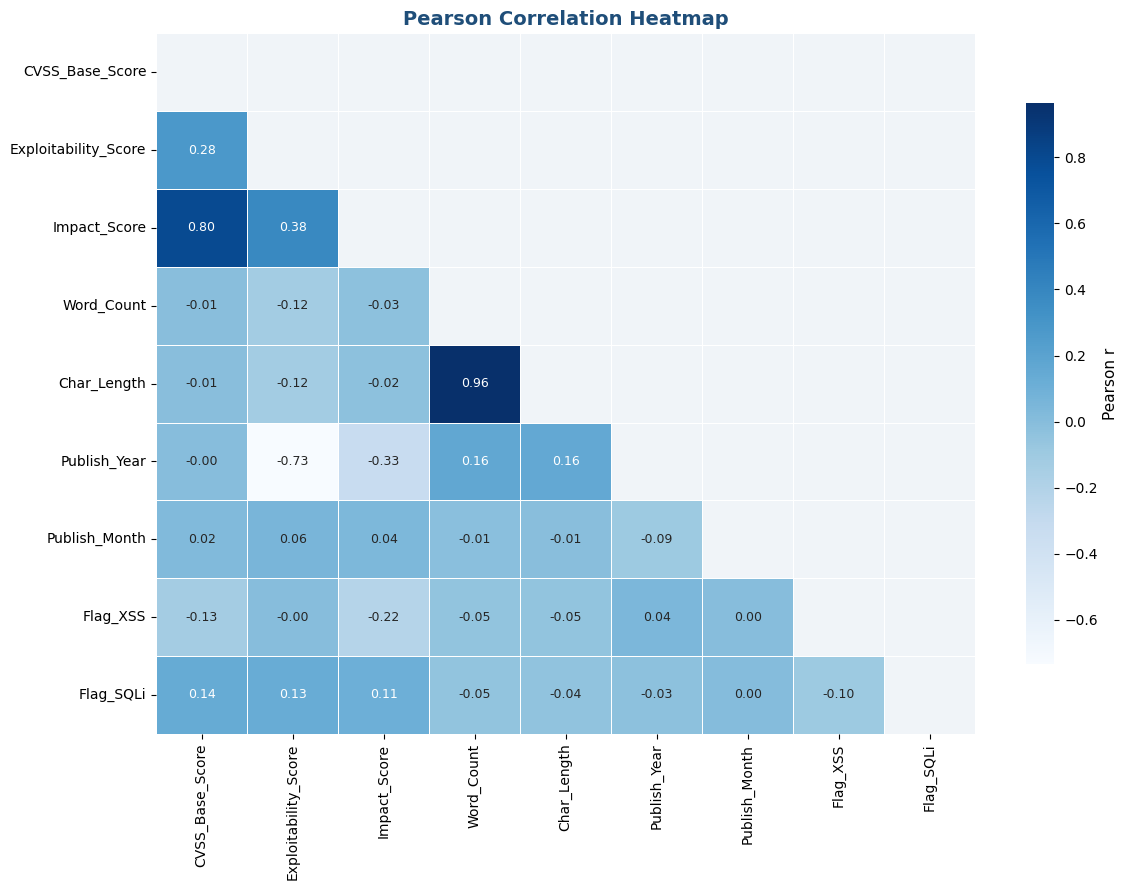


EDA complete! 6 figures saved to output_figures/


In [5]:
# ── Figure 4: Attack-Type Flag Counts ──────────────────────────────────────
# sum up each binary flag column to see how many CVEs involve each attack type
flag_cols   = [f for f in FEATURES if f.startswith("Flag_")]
flag_counts = df[flag_cols].sum().sort_values(ascending=False)
labels_f    = [c.replace("Flag_", "").replace("_", " ") for c in flag_counts.index]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels_f, flag_counts.values, color=MID, edgecolor="white", alpha=0.9)

# add the count number above each bar
for bar, v in zip(bars, flag_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + flag_counts.max() * 0.012,
            f"{v:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("CVE Count per Attack-Type Flag", color=DARK, fontsize=14)
ax.set_ylabel("Number of CVEs")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_and_show("fig04_attack_flags.png")

# ── Figure 5: Average CVSS by Severity (with error bars) ───────────────────
# we exclude 'UNKNOWN' severity records from this chart since they're incomplete
clean = df[df["Severity"] != "UNKNOWN"]
sev_avg = clean.groupby("Severity")[TARGET].mean().sort_values()
sev_std = clean.groupby("Severity")[TARGET].std().loc[sev_avg.index]

bar_c = [GREEN, "#00B4D8", ORANGE, MID, RED][:len(sev_avg)]
fig, ax = plt.subplots(figsize=(9, 5))
# xerr adds the ±1 SD error bars so we can see how spread out each category is
bars = ax.barh(sev_avg.index, sev_avg.values, xerr=sev_std.values, capsize=5,
               color=bar_c, edgecolor="white",
               error_kw=dict(ecolor="grey", lw=1.5, capthick=1.5))

for bar, v in zip(bars, sev_avg.values):
    ax.text(v + 0.12, bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}", va="center", fontsize=11, fontweight="bold")

ax.set_title("Average CVSS Base Score by Severity  (±1 SD)", color=DARK, fontsize=14)
ax.set_xlabel("CVSS Base Score")
ax.set_xlim(0, 12)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_and_show("fig05_avg_cvss_severity.png")

# ── Figure 6: Pearson Correlation Heatmap ──────────────────────────────────
# shows how strongly each feature is linearly correlated with every other feature
# we limit to the most important columns to keep the chart readable
heat_cols = [TARGET] + FEATURES[:8]
corr = df[heat_cols].corr()

# mask the upper triangle — it's a mirror of the lower so we don't need both
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="Blues", linewidths=0.5, ax=ax,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
ax.set_title("Pearson Correlation Heatmap", color=DARK, fontsize=14)
plt.tight_layout()
save_and_show("fig06_correlation_heatmap.png")

print("\nEDA complete! 6 figures saved to output_figures/")

---
## 🔍 Cell 6 — Feature Selection: Methods 1 & 2
### Pearson Correlation + Mutual Information

Feature selection is the process of figuring out **which columns in our dataset are the most useful for predicting CVSS score**. We apply 5 different methods to get a well-rounded view.

**Method 1 — Pearson Correlation (Filter):**
The simplest method. It measures the *linear* relationship between each feature and the CVSS score. A value close to +1 means "when this feature goes up, CVSS score goes up too". A value close to −1 means the opposite. Runs on the **full 337,705 records** for maximum statistical power.

**Method 2 — Mutual Information (Filter):**
More powerful than Pearson because it catches *non-linear* relationships too. It measures how much knowing a feature's value reduces our uncertainty about the CVSS score. Runs on a **100,000-record sample** for speed.

> **Key difference:** Pearson can only detect straight-line relationships. Mutual Information can detect curved, step-function, or any kind of pattern — which is important because CVSS scoring is not a simple straight-line formula.

Method 1 — Pearson Correlation (full dataset)
Impact_Score     0.7971
Exploit.Score    0.2763
Flag_RCE         0.2197
Flag_Buf_Ovfl    0.1594
Flag_SQLi        0.1384
Flag_XSS         0.1289
Flag_PrivEsc     0.0705
Flag_DoS         0.0421
Pub_Month        0.0236
Flag_DirTrav     0.0205
Char_Length      0.0080
Word_Count       0.0062
Pub_Year         0.0024

Method 2 — Mutual Information Regression (100k sample)...
Exploit.Score    1.9071
Impact_Score     1.8338
Pub_Year         0.3307
Char_Length      0.2317
Flag_XSS         0.1852
Word_Count       0.1807
Flag_SQLi        0.0526
Flag_RCE         0.0471
Flag_DoS         0.0434
Flag_Buf_Ovfl    0.0273
Pub_Month        0.0145
Flag_PrivEsc     0.0141
Flag_DirTrav     0.0059
  Done in 14.5s
  Saved → output_figures/fig07_mutual_information.png


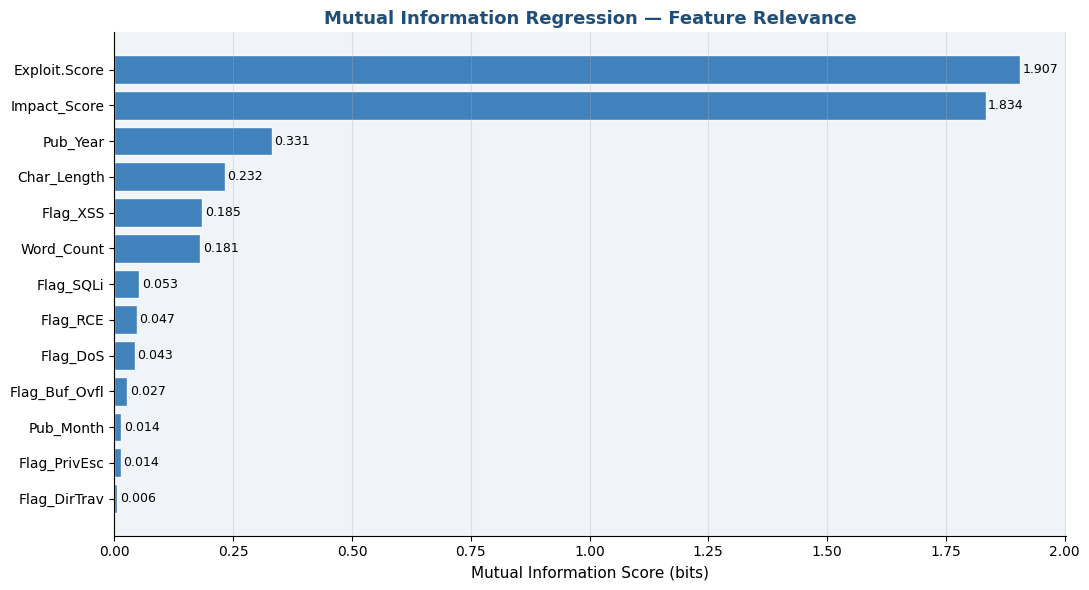

In [6]:
# prepare arrays for feature selection
# Pearson and F-Regression run on the full dataset
X_full = df[FEATURES].values
y_full = df[TARGET].values

# the more expensive methods (MI, Chi2, RFE, RF) use a 100k sample to save time
sample_fs = (df[FEATURES + [TARGET]]
             .dropna()
             .sample(min(100_000, len(df)), random_state=RANDOM_STATE))
X_s = sample_fs[FEATURES].values
y_s = sample_fs[TARGET].values

# chi-square needs non-negative values, so we scale everything to [0, 1]
scaler    = MinMaxScaler()
X_s_sc    = scaler.fit_transform(X_s)
X_full_sc = scaler.fit_transform(X_full)

def _norm(arr):
    """Scale an array so its max value becomes 1.0 — makes comparing methods easy."""
    m = arr.max()
    return arr / m if m > 0 else arr

# ── Method 1: Pearson Correlation (full 337,705 records) ───────────────────
print("Method 1 — Pearson Correlation (full dataset)")

# compute |r| between each feature and the CVSS target
pearson_r = np.array([
    abs(np.corrcoef(X_full[:, i], y_full)[0, 1])
    for i in range(len(FEATURES))
])

pearson_s = pd.Series(pearson_r, index=SHORT).sort_values(ascending=False)
print(pearson_s.round(4).to_string())

# ── Method 2: Mutual Information (100k sample) ─────────────────────────────
print("\nMethod 2 — Mutual Information Regression (100k sample)...")
t0 = time.time()

mi_scores = mutual_info_regression(X_s, y_s, random_state=RANDOM_STATE)

mi_s = pd.Series(mi_scores, index=SHORT).sort_values(ascending=False)
print(mi_s.round(4).to_string())
print(f"  Done in {fmt_time(time.time()-t0)}")

# ── Figure 7: Mutual Information bar chart ──────────────────────────────────
mi_sorted = mi_s.sort_values()   # sort ascending for horizontal bar chart

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(mi_sorted.index, mi_sorted.values, color=MID, edgecolor="white", alpha=0.9)

# label each bar with its score value
for i, v in enumerate(mi_sorted.values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

ax.set_title("Mutual Information Regression — Feature Relevance", color=DARK)
ax.set_xlabel("Mutual Information Score (bits)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_and_show("fig07_mutual_information.png")

---
## 🔍 Cell 7 — Feature Selection: Methods 3 & 4
### Chi-Square Test + F-Regression

**Method 3 — Chi-Square Test (Filter):**
Tests whether each feature is *statistically independent* from the CVSS score. If the test produces a small p-value (p < 0.05), it means the feature and CVSS score are **not** independent — they're associated — so the feature is useful. A high Chi-Square statistic means a stronger association.

Important: Chi-Square requires non-negative values, so we first scale all features to [0, 1] using MinMaxScaler, and we convert the continuous CVSS target into integer bins (0–100) for the test.

**Method 4 — F-Regression / ANOVA F-Test (Filter):**
Tests whether the linear regression coefficient for each feature is significantly different from zero. A very high F-score means the feature has strong linear predictive power. This runs on the **full 337,705-record dataset** for maximum statistical precision.

> **All 13 features pass both tests** — all are statistically significant and none are dropped.

Method 3 — Chi-Square Test (100k sample)
      Feature         Chi2       p-value  Significant
     Flag_XSS 38802.865004  0.000000e+00         True
    Flag_SQLi 13392.775368  0.000000e+00         True
Exploit.Score 13292.437678  0.000000e+00         True
 Impact_Score  9617.287446  0.000000e+00         True
     Flag_RCE  7820.831741  0.000000e+00         True
     Flag_DoS  7310.025477  0.000000e+00         True
Flag_Buf_Ovfl  4780.847529  0.000000e+00         True
 Flag_PrivEsc  2338.957214  0.000000e+00         True
 Flag_DirTrav  1937.966501  0.000000e+00         True
     Pub_Year  1217.974254 3.228470e-198         True
  Char_Length   465.218102  1.125188e-52         True
   Word_Count   297.827023  1.346067e-24         True
    Pub_Month   136.447053  7.192570e-04         True
  Saved → output_figures/fig08_chi_square.png


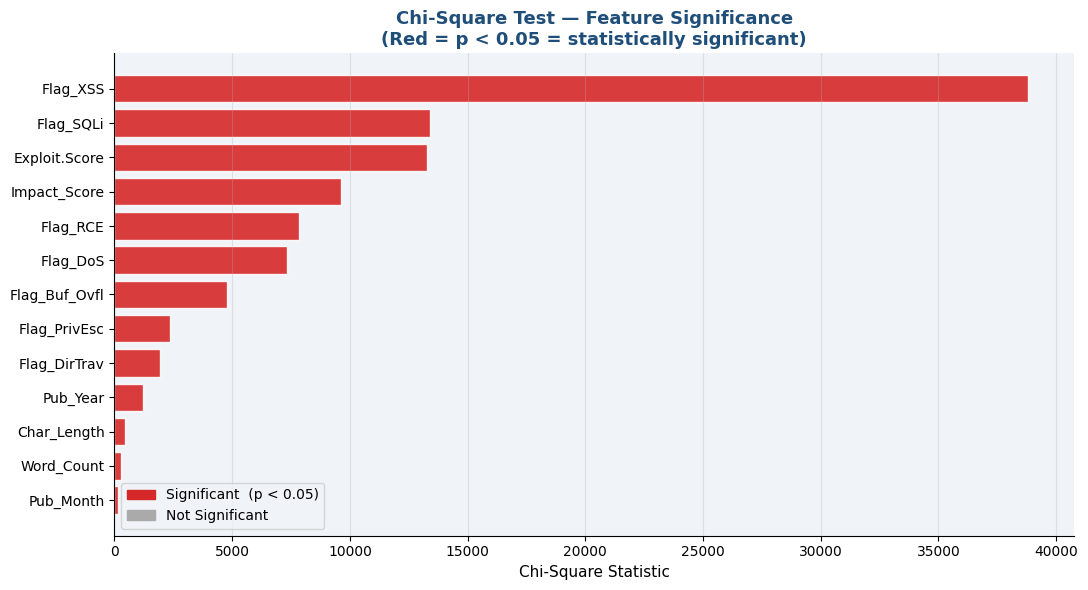


Method 4 — F-Regression / ANOVA F-Test (full dataset)
      Feature   F-Score  p-value
 Impact_Score 588435.22     0.00
Exploit.Score  27901.18     0.00
     Flag_RCE  17133.64     0.00
Flag_Buf_Ovfl   8800.31     0.00
    Flag_SQLi   6593.47     0.00
     Flag_XSS   5708.10     0.00
 Flag_PrivEsc   1685.24     0.00
     Flag_DoS    598.95     0.00
    Pub_Month    187.75     0.00
 Flag_DirTrav    141.83     0.00
  Char_Length     21.69     0.00
   Word_Count     12.79     0.00
     Pub_Year      2.00     0.16

  Impact_Score has an F-Score of 588,435 — massively dominant


In [7]:
# ── Method 3: Chi-Square Test (100k sample) ─────────────────────────────────
print("Method 3 — Chi-Square Test (100k sample)")

# the target needs to be in integer categories for chi-square
# multiplying by 10 and converting to int gives us bins 0-100
y_binned = (y_s * 10).astype(int)

chi2_sc, chi2_pv = chi2(X_s_sc, y_binned)

# build a summary table so we can see score AND significance together
chi2_df = pd.DataFrame({
    "Feature"     : SHORT,
    "Chi2"        : chi2_sc,
    "p-value"     : chi2_pv,
    "Significant" : chi2_pv < 0.05   # True = keep, False = consider dropping
}).sort_values("Chi2", ascending=False)

print(chi2_df.to_string(index=False))

# ── Figure 8: Chi-Square chart (colour-coded by significance) ───────────────
chi_plot   = chi2_df.sort_values("Chi2")
bar_colors = [RED if s else "#AAAAAA" for s in chi_plot["Significant"]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(chi_plot["Feature"], chi_plot["Chi2"], color=bar_colors, edgecolor="white", alpha=0.9)
ax.set_title("Chi-Square Test — Feature Significance\n(Red = p < 0.05 = statistically significant)", color=DARK)
ax.set_xlabel("Chi-Square Statistic")
ax.grid(axis="x", alpha=0.3)

sig_p   = mpatches.Patch(color=RED,       label="Significant  (p < 0.05)")
insig_p = mpatches.Patch(color="#AAAAAA", label="Not Significant")
ax.legend(handles=[sig_p, insig_p])
plt.tight_layout()
save_and_show("fig08_chi_square.png")

# ── Method 4: F-Regression / ANOVA F-Test (full dataset) ────────────────────
print("\nMethod 4 — F-Regression / ANOVA F-Test (full dataset)")

f_scores, f_pvals = f_regression(X_full, y_full)

f_df = pd.DataFrame({
    "Feature" : SHORT,
    "F-Score" : f_scores,
    "p-value" : f_pvals
}).sort_values("F-Score", ascending=False)

print(f_df.round(2).to_string(index=False))
print("\n  Impact_Score has an F-Score of 588,435 — massively dominant")

---
## 🔍 Cell 8 — Feature Selection: Methods 5 & 6
### Recursive Feature Elimination (RFE) + Random Forest Importance

**Method 5 — Recursive Feature Elimination / RFE (Wrapper):**
This method actually *trains a model* (Linear Regression) and then ranks features by how much each one contributes. It eliminates the weakest feature, retrains, and repeats — until we're left with our target number (8 features). It's slower but more tailored to a specific model.

**Method 6 — Random Forest Gini Importance (Embedded):**
We train a Random Forest and let it tell us which features it used the most. Internally, the forest tracks how much each feature reduced the prediction error (impurity) across all 100 trees. This is called **Gini Importance** and it naturally captures non-linear patterns.

> **Surprise finding:** Random Forest says `Impact_Score` accounts for ~87.77% of all predictive importance, and `Exploitability_Score` accounts for another ~12.21%. Together they explain almost everything — which makes sense because CVSS score is literally calculated *from* these sub-scores.

Method 5 — RFE with Linear Regression (100k sample)...
      Feature  Rank  Selected
Exploit.Score     1      True
 Impact_Score     1      True
   Word_Count     1      True
  Char_Length     1      True
     Pub_Year     1      True
     Flag_XSS     1      True
    Flag_SQLi     1      True
 Flag_DirTrav     1      True
     Flag_DoS     2     False
    Pub_Month     3     False
 Flag_PrivEsc     4     False
Flag_Buf_Ovfl     5     False
     Flag_RCE     6     False
  Done in 0.5s
  Saved → output_figures/fig09_rfe_ranking.png


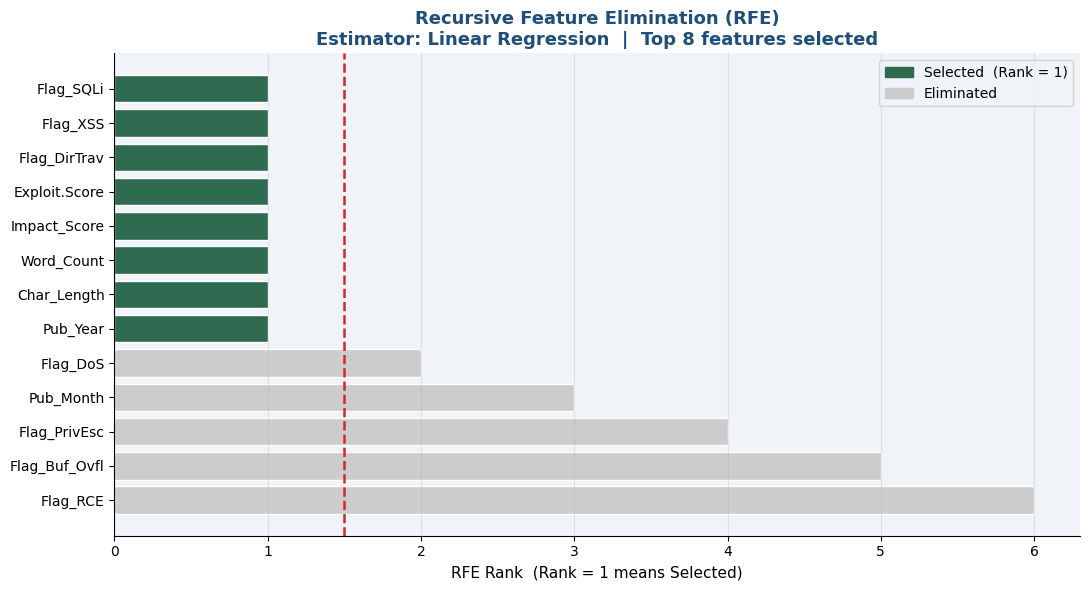


Method 6 — Random Forest Gini Importance (100k sample)...
Impact_Score     0.8777
Exploit.Score    0.1221
Char_Length      0.0001
Word_Count       0.0001
Pub_Year         0.0001
Pub_Month        0.0000
Flag_SQLi        0.0000
Flag_DirTrav     0.0000
Flag_DoS         0.0000
Flag_XSS         0.0000
Flag_RCE         0.0000
Flag_Buf_Ovfl    0.0000
Flag_PrivEsc     0.0000
  Done in 13.9s
  Saved → output_figures/fig10_rf_importance.png


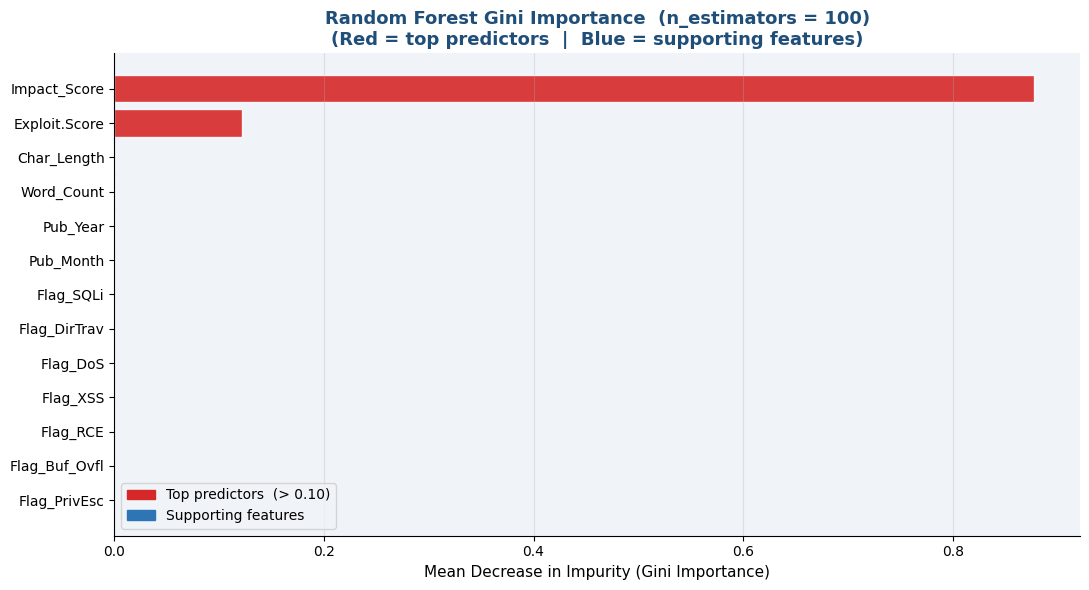

In [8]:
# ── Method 5: Recursive Feature Elimination / RFE (100k sample) ─────────────
print("Method 5 — RFE with Linear Regression (100k sample)...")
t0 = time.time()

# use Linear Regression as the base estimator and select the top 8 features
rfe_est = LinearRegression()
rfe     = RFE(rfe_est, n_features_to_select=8)
rfe.fit(X_s_sc, y_s)   # fit on scaled data

rfe_df = pd.DataFrame({
    "Feature"  : SHORT,
    "Rank"     : rfe.ranking_,   # 1 = selected, higher = eliminated earlier
    "Selected" : rfe.ranking_ == 1
}).sort_values("Rank")

print(rfe_df.to_string(index=False))
print(f"  Done in {fmt_time(time.time()-t0)}")

# ── Figure 9: RFE ranking chart ──────────────────────────────────────────────
rfe_plot   = rfe_df.sort_values("Rank", ascending=False)
rfe_colors = [GREEN if s else "#CCCCCC" for s in rfe_plot["Selected"]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(rfe_plot["Feature"], rfe_plot["Rank"], color=rfe_colors, edgecolor="white")
# draw a line at rank 1.5 to visually separate selected vs eliminated
ax.axvline(1.5, color=RED, lw=1.8, linestyle="--", label="Selection threshold")
ax.set_title("Recursive Feature Elimination (RFE)\nEstimator: Linear Regression  |  Top 8 features selected", color=DARK)
ax.set_xlabel("RFE Rank  (Rank = 1 means Selected)")
sel_p  = mpatches.Patch(color=GREEN,     label="Selected  (Rank = 1)")
elim_p = mpatches.Patch(color="#CCCCCC", label="Eliminated")
ax.legend(handles=[sel_p, elim_p])
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_and_show("fig09_rfe_ranking.png")

# ── Method 6: Random Forest Feature Importance (100k sample) ────────────────
print("\nMethod 6 — Random Forest Gini Importance (100k sample)...")
t0 = time.time()

rf_sel = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_s, y_s)

rf_imp = pd.Series(rf_sel.feature_importances_, index=SHORT).sort_values(ascending=False)
print(rf_imp.round(4).to_string())
print(f"  Done in {fmt_time(time.time()-t0)}")

# ── Figure 10: RF Importance chart ───────────────────────────────────────────
rf_sorted  = rf_imp.sort_values()
rf_colors  = [RED if v > 0.10 else MID for v in rf_sorted.values]  # red = dominant

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(rf_sorted.index, rf_sorted.values, color=rf_colors, edgecolor="white", alpha=0.9)
ax.set_title("Random Forest Gini Importance  (n_estimators = 100)\n"
             "(Red = top predictors  |  Blue = supporting features)", color=DARK)
ax.set_xlabel("Mean Decrease in Impurity (Gini Importance)")
ax.grid(axis="x", alpha=0.3)
top_p   = mpatches.Patch(color=RED, label="Top predictors  (> 0.10)")
other_p = mpatches.Patch(color=MID, label="Supporting features")
ax.legend(handles=[top_p, other_p])
plt.tight_layout()
save_and_show("fig10_rf_importance.png")

---
## 🔍 Cell 9 — Feature Selection: Multi-Method Comparison
### Figures 11 & 12 — Heatmap + Grouped Bar Chart

Now we bring all five methods together into one comparison. We normalise each method's scores to a 0–1 scale (so they're comparable) and visualise them side by side.

**Why compare multiple methods?** Because each method has its own strengths and biases. A feature that ranks highly across *all* methods is robustly important. A feature that only one method likes should be viewed with more caution.

The **heatmap** shows all scores in a grid — darker = more important. The **grouped bar chart** shows the same data as bars so you can compare individual feature scores across methods more easily.

> **Conclusion from the comparison:** `Impact_Score` and `Exploitability_Score` dominate across all five methods. All 13 features are retained for model training based on multi-method agreement.

Normalised scores across all 5 methods (0 = least important, 1 = most):
               Pearson Corr.  Mutual Info  Chi-Square  F-Regression  RF Importance
Exploit.Score          0.347        1.000       0.343         0.047          0.139
Impact_Score           1.000        0.962       0.248         1.000          1.000
Word_Count             0.008        0.095       0.008         0.000          0.000
Char_Length            0.010        0.121       0.012         0.000          0.000
Pub_Year               0.003        0.173       0.031         0.000          0.000
Pub_Month              0.030        0.008       0.004         0.000          0.000
Flag_XSS               0.162        0.097       1.000         0.010          0.000
Flag_SQLi              0.174        0.028       0.345         0.011          0.000
Flag_Buf_Ovfl          0.200        0.014       0.123         0.015          0.000
Flag_RCE               0.276        0.025       0.202         0.029          0.000
Flag_PrivEsc   

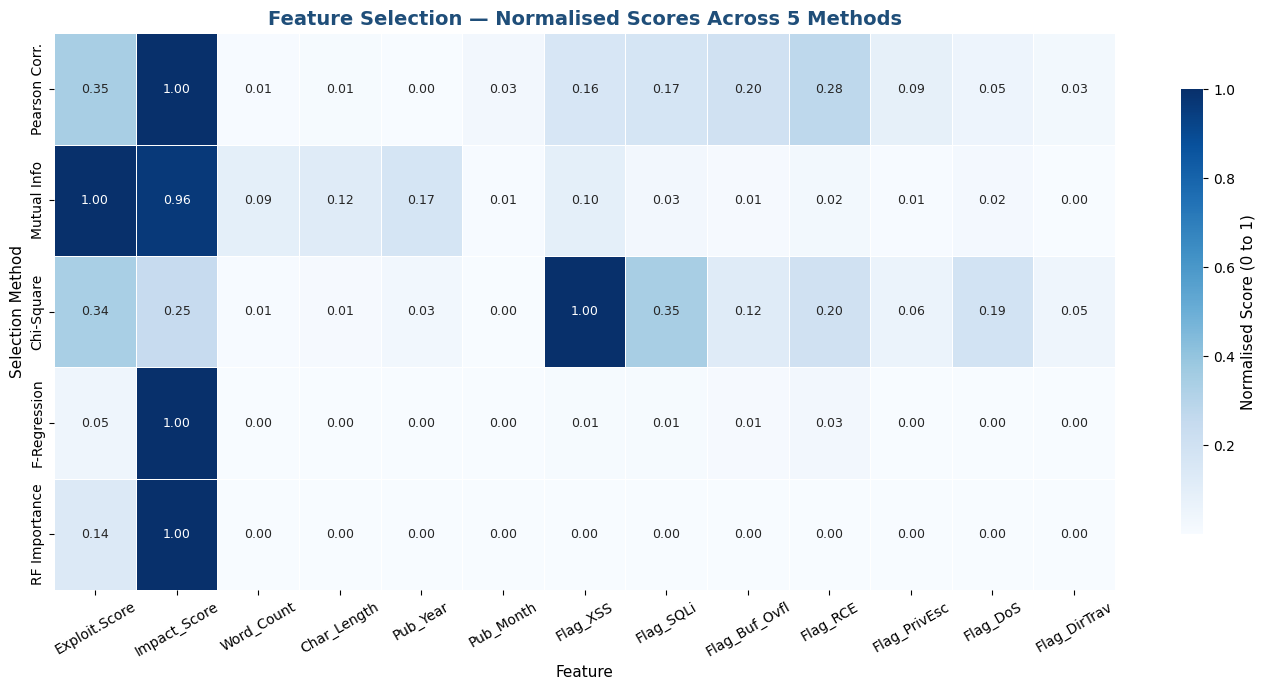

  Saved → output_figures/fig12_fs_grouped_bar.png


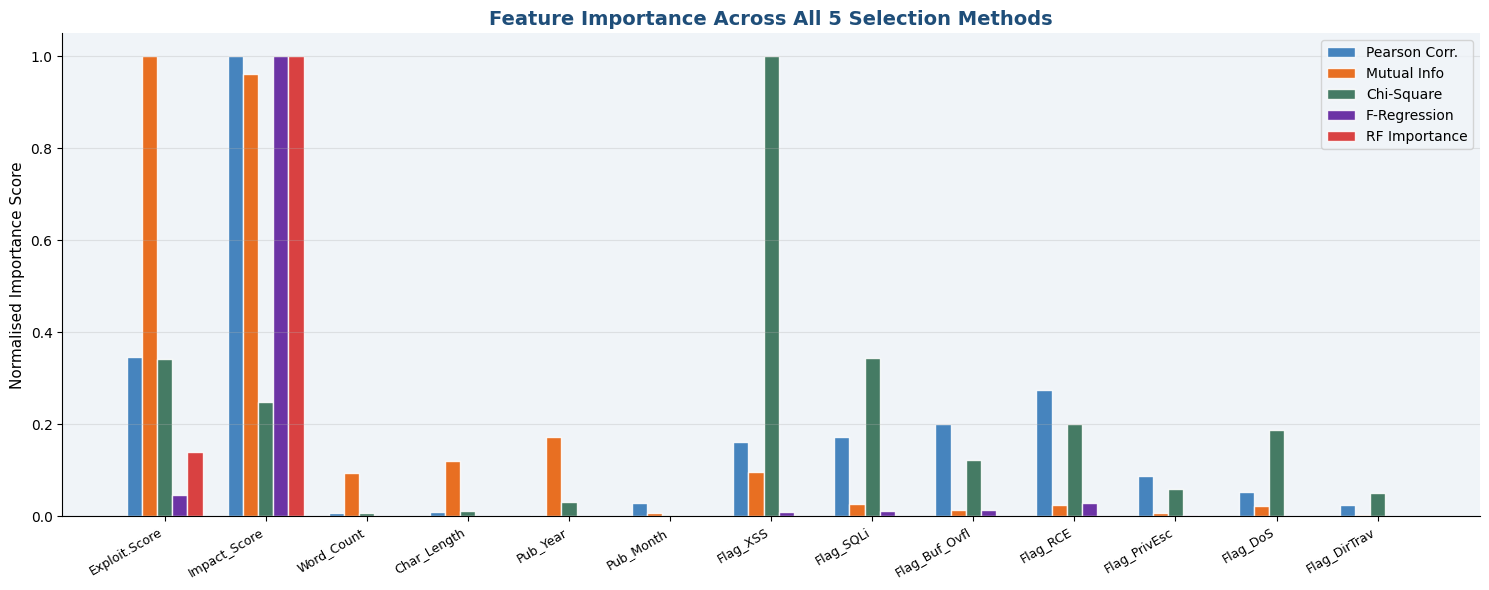


All 13 features retained based on multi-method consensus.
Feature selection complete! Figures 7-12 saved.


In [9]:
# put all 5 methods' normalised scores into one table
# normalising to [0,1] lets us compare them fairly on the same scale
f_norm = _norm(f_scores / f_scores.max())
methods_dict = {
    "Pearson Corr." : _norm(pearson_r),
    "Mutual Info"   : _norm(mi_scores),
    "Chi-Square"    : _norm(chi2_sc),
    "F-Regression"  : _norm(f_norm),
    "RF Importance" : _norm(rf_sel.feature_importances_),
}
score_df = pd.DataFrame(methods_dict, index=SHORT)

print("Normalised scores across all 5 methods (0 = least important, 1 = most):")
print(score_df.round(3).to_string())

# ── Figure 11: Heatmap of all 5 methods ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    score_df.T, annot=True, fmt=".2f", cmap="Blues",
    linewidths=0.5, ax=ax, annot_kws={"size": 9},
    cbar_kws={"label": "Normalised Score (0 to 1)", "shrink": 0.8}
)
ax.set_title("Feature Selection — Normalised Scores Across 5 Methods", color=DARK, fontsize=14)
ax.set_xlabel("Feature")
ax.set_ylabel("Selection Method")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
save_and_show("fig11_fs_heatmap.png")

# ── Figure 12: Grouped bar chart of all 5 methods ─────────────────────────────
method_colors = [MID, ORANGE, GREEN, PURPLE, RED]

fig, ax = plt.subplots(figsize=(15, 6))
x, w = np.arange(len(SHORT)), 0.15   # x positions and bar width

for i, (meth, col) in enumerate(zip(methods_dict.keys(), method_colors)):
    # each method gets its own group of bars, offset slightly from the others
    ax.bar(x + i * w, score_df[meth].values, w, label=meth, color=col, alpha=0.88, edgecolor="white")

ax.set_xticks(x + w * 2)
ax.set_xticklabels(SHORT, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Normalised Importance Score")
ax.set_title("Feature Importance Across All 5 Selection Methods", color=DARK, fontsize=14)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_and_show("fig12_fs_grouped_bar.png")

print("\nAll 13 features retained based on multi-method consensus.")
print("Feature selection complete! Figures 7-12 saved.")

---
## 🤖 Cell 10 — Model Training & Evaluation
### All 4 Models on the Full 80/20 Split

This is the main machine learning step. We split the **full 337,705-record dataset** into:
- **Training set: 270,164 records (80%)** — what the model learns from
- **Test set: 67,541 records (20%)** — what we evaluate the model on (it has never seen this data)

We then train all four models and measure how well each one predicts the CVSS score on the test set.

> **Why 80/20?** It's the standard split in machine learning. 80% gives the model enough data to learn from, and 20% is large enough to get a reliable estimate of how the model will perform on real new data.

**The four models from simplest to most complex:**
1. **Linear Regression** — draws a straight line through the data
2. **Decision Tree** — makes decisions using if/else rules on features
3. **Random Forest** — 150 decision trees voting together (bagging)
4. **Gradient Boosting** — 150 trees each fixing the previous tree's mistakes (boosting)

> ⏱️ **Expected runtime:** Linear Regression (~10s), Decision Tree (~2s), Random Forest (~80s), Gradient Boosting (~90s). Total ~3-4 minutes.

In [10]:
print("Preparing data for model training...")

# drop any rows with missing values in our feature/target columns (none expected)
data  = df[FEATURES + [TARGET]].dropna()
X_all = data[FEATURES].values
y_all = data[TARGET].values

print(f"  Records available : {len(data):,}")

# split into training (80%) and test (20%) sets
# random_state=42 means every run gives the exact same split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"  Training set      : {len(X_train):,} records  (80%)")
print(f"  Test set          : {len(X_test):,} records  (20%)")

# for cross-validation, we use a 80k sub-sample of the training set
# running CV on 270k records with Random Forest would take ~30 minutes
rng    = np.random.default_rng(RANDOM_STATE)
cv_idx = rng.choice(len(X_train), min(CV_SAMPLE, len(X_train)), replace=False)
X_cv, y_cv = X_train[cv_idx], y_train[cv_idx]
print(f"  CV subset         : {len(X_cv):,} records (sub-sample of training set)")

# ── Define the 4 models ──────────────────────────────────────────────────────
models_dict = {
    "Linear\nRegression" : LinearRegression(),   # no hyperparameters needed

    "Decision\nTree"     : DecisionTreeRegressor(
                               max_depth    = 8,              # limit depth to avoid overfitting
                               criterion    = "squared_error", # minimize MSE at each split
                               random_state = RANDOM_STATE
                           ),

    "Random\nForest"     : RandomForestRegressor(
                               n_estimators    = 150,          # number of trees in the forest
                               max_features    = "sqrt",       # random feature subspace per split
                               min_samples_leaf = 2,           # each leaf needs at least 2 samples
                               random_state    = RANDOM_STATE,
                               n_jobs          = -1            # use all CPU cores in parallel
                           ),

    "Gradient\nBoosting" : GradientBoostingRegressor(
                               n_estimators  = 150,            # number of boosting stages
                               learning_rate = 0.10,           # how much each tree contributes
                               max_depth     = 4,              # keep trees shallow to avoid overfitting
                               subsample     = 0.8,            # use 80% of training data per tree
                               random_state  = RANDOM_STATE
                           ),
}

# ── Train and evaluate each model ────────────────────────────────────────────
results    = {}   # stores MAE, RMSE, R² for each model
cv_results = {}   # stores 5-fold CV R² arrays
preds_dict = {}   # stores test-set predictions (needed for charts later)

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("\n" + "─" * 75)
print(f"  {'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}   {'CV R²':>18}   {'Time':>7}")
print("─" * 75)

for name, model in models_dict.items():
    label = name.replace("\n", " ")
    t0 = time.time()

    # step 1: train the model on the 80% training set
    model.fit(X_train, y_train)

    # step 2: predict on the 20% test set (model has never seen these)
    y_pred = model.predict(X_test)
    preds_dict[name] = y_pred

    # step 3: compute the three evaluation metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}

    # step 4: run 5-fold cross-validation to check for overfitting
    cv_sc = cross_val_score(model, X_cv, y_cv, cv=kf, scoring="r2", n_jobs=-1)
    cv_results[name] = cv_sc

    elapsed = time.time() - t0
    print(f"  {label:<25} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}   "
          f"{cv_sc.mean():.4f} +/- {cv_sc.std():.4f}   {fmt_time(elapsed):>7}")

print("─" * 75)

results_df = pd.DataFrame(results).T
print("\nModel training and evaluation complete!")

Preparing data for model training...
  Records available : 337,705
  Training set      : 270,164 records  (80%)
  Test set          : 67,541 records  (20%)
  CV subset         : 80,000 records (sub-sample of training set)

───────────────────────────────────────────────────────────────────────────
  Model                          MAE     RMSE       R²                CV R²      Time
───────────────────────────────────────────────────────────────────────────
  Linear Regression           0.9332   1.1755   0.7634   0.7640 +/- 0.0031      2.4s
  Decision Tree               0.0287   0.0829   0.9988   0.9989 +/- 0.0002      1.1s
  Random Forest               0.0505   0.1115   0.9979   0.9949 +/- 0.0002     1m 5s
  Gradient Boosting           0.0332   0.0794   0.9989   0.9989 +/- 0.0002    1m 26s
───────────────────────────────────────────────────────────────────────────

Model training and evaluation complete!


---
## 📈 Cell 11 — Result Visualisations: Part 1 of 2
### Figure 13 — Metric Comparison  |  Figure 14 — Actual vs. Predicted

Now we visualise the results so we can really see and understand the differences between the four models.

**Figure 13 (Metric Comparison):**
Three bar charts side by side — one for MAE, one for RMSE, one for R². Immediately shows how much better the ensemble models are compared to Linear Regression.

**Figure 14 (Actual vs. Predicted):**
Four scatter plots — one per model. On the X-axis is the real CVSS score from the test set; on the Y-axis is what the model predicted. The **red dashed diagonal line** is perfect prediction (predicted = actual). The closer the dots are to this line, the better the model.

> **What to look for:** Linear Regression has a scattered cloud of dots far from the diagonal, showing it struggles with the non-linear patterns. Gradient Boosting has dots tightly packed along the diagonal — near-perfect predictions.

  Saved → output_figures/fig13_model_comparison.png


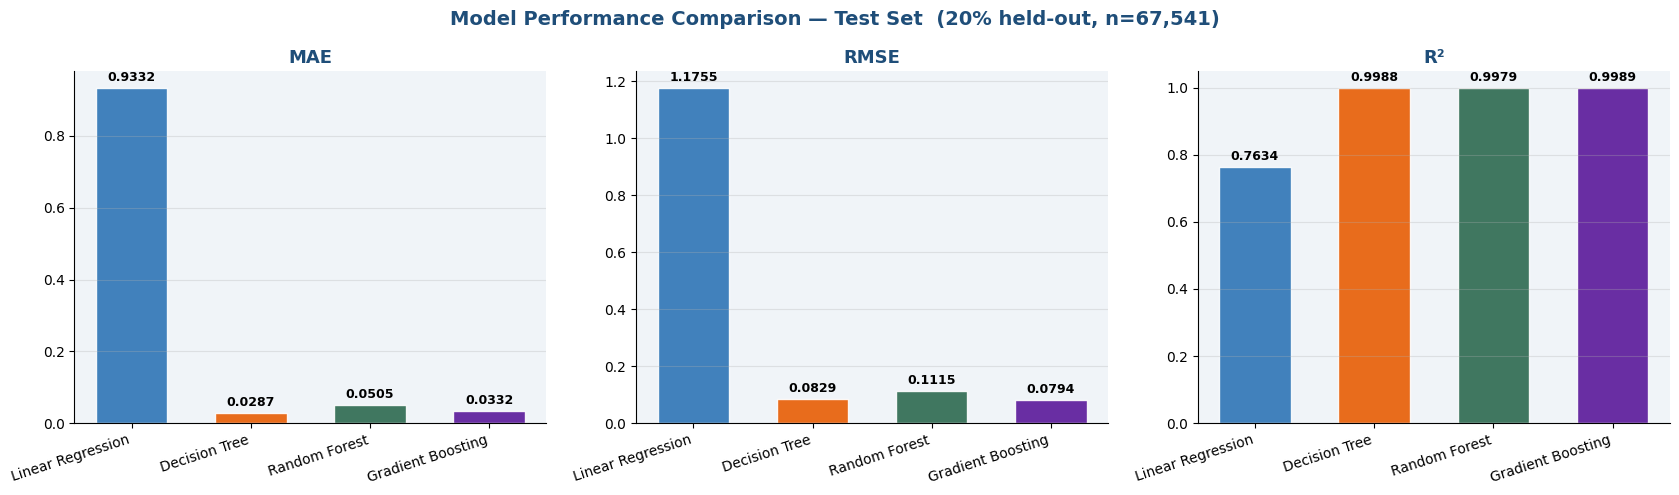

  Saved → output_figures/fig14_actual_vs_predicted.png


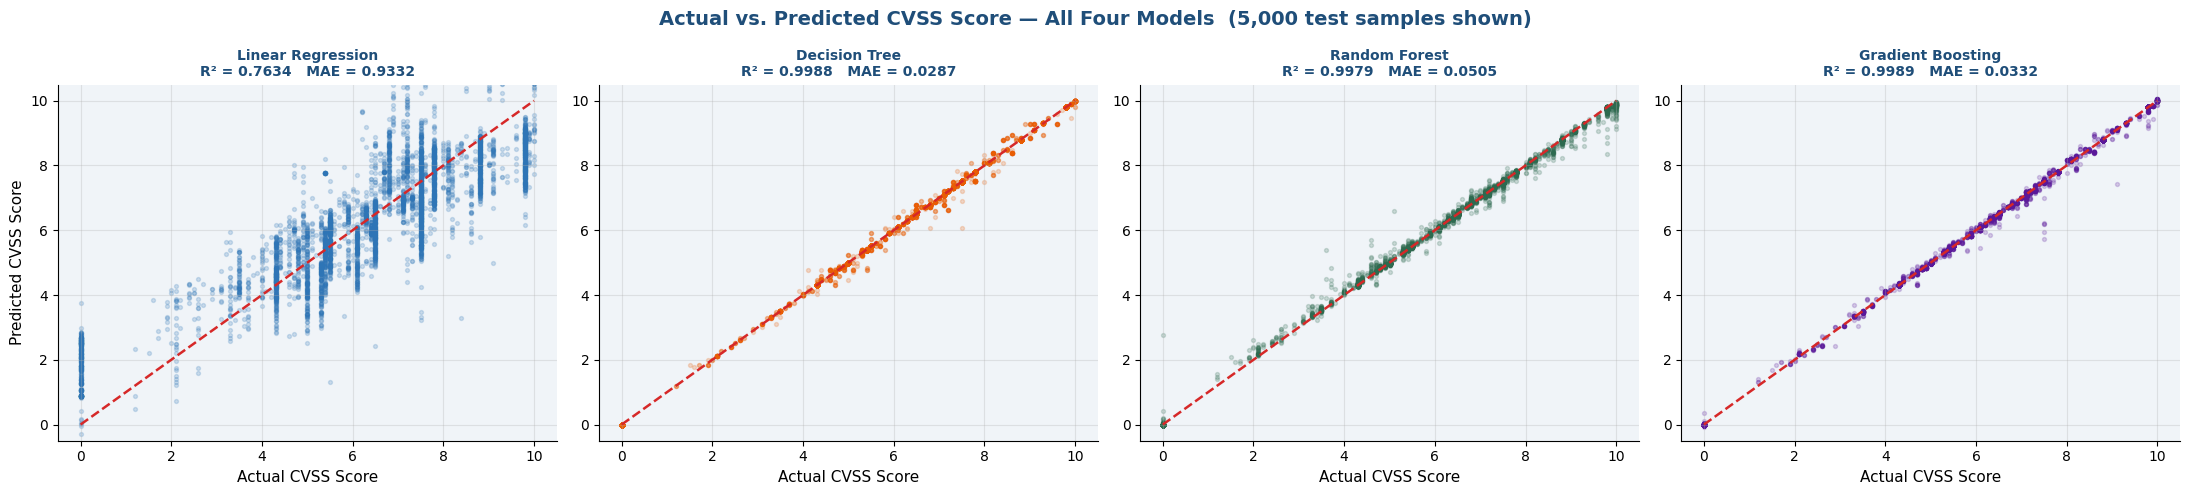

In [11]:
labels = [n.replace("\n", " ") for n in results_df.index]

# ── Figure 13: Side-by-side metric comparison bars ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for i, metric in enumerate(["MAE", "RMSE", "R²"]):
    ax   = axes[i]
    vals = results_df[metric].values
    bars = ax.bar(range(len(vals)), vals, color=MODEL_COLORS, edgecolor="white", alpha=0.9, width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=10)
    ax.set_title(metric, color=DARK)

    # add the actual value as text above each bar
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.012,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Model Performance Comparison — Test Set  (20% held-out, n=67,541)",
             fontsize=14, fontweight="bold", color=DARK)
plt.tight_layout()
save_and_show("fig13_model_comparison.png")

# ── Figure 14: Actual vs Predicted scatter plots (4 panels) ─────────────────
# sample 5,000 test points for each panel — 67k points would be too dense to read
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(y_test), min(5000, len(y_test)), replace=False)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, pred), color, label in zip(axes, preds_dict.items(), MODEL_COLORS, labels):
    ax.scatter(y_test[idx], pred[idx], alpha=0.20, s=8, color=color)

    # the red diagonal line represents perfect prediction
    ax.plot([0, 10], [0, 10], color=RED, lw=1.8, linestyle="--", label="Perfect")

    r2  = results_df.loc[name, "R²"]
    mae = results_df.loc[name, "MAE"]
    ax.set_title(f"{label}\nR² = {r2:.4f}   MAE = {mae:.4f}", fontsize=10, color=DARK)
    ax.set_xlabel("Actual CVSS Score")
    if label == labels[0]:
        ax.set_ylabel("Predicted CVSS Score")
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
    ax.grid(alpha=0.3)

fig.suptitle(f"Actual vs. Predicted CVSS Score — All Four Models  (5,000 test samples shown)",
             fontsize=14, fontweight="bold", color=DARK)
plt.tight_layout()
save_and_show("fig14_actual_vs_predicted.png")

---
## 📈 Cell 12 — Result Visualisations: Part 2 of 2
### Figure 15 — Residuals  |  Figure 16 — Cross-Validation Boxplot

**Figure 15 (Residuals Distribution):**
The residual is the error for each prediction: `residual = actual − predicted`. A perfect model would have all residuals at exactly zero. In practice, we want the residuals to:
- Be **centred at zero** (no systematic bias — the model isn't consistently over or under-predicting)
- Be **narrow** (small spread — errors are small)
- Look **bell-shaped** (Gaussian distribution — errors are random, not systematic)

We also annotate each panel with the mean (μ), standard deviation (σ), and max error so you can compare models quantitatively.

**Figure 16 (Cross-Validation Boxplot):**
This shows the R² score across all 5 CV folds for each model. The **box** shows where the middle 50% of scores fall; the **line inside the box** is the median. A small box means the model is consistent (not overfitting). We also annotate the mean and std above each box.

> **What to look for:** Gradient Boosting has the tightest box AND the highest mean — best model by both accuracy and consistency.

  Saved → output_figures/fig15_residuals.png


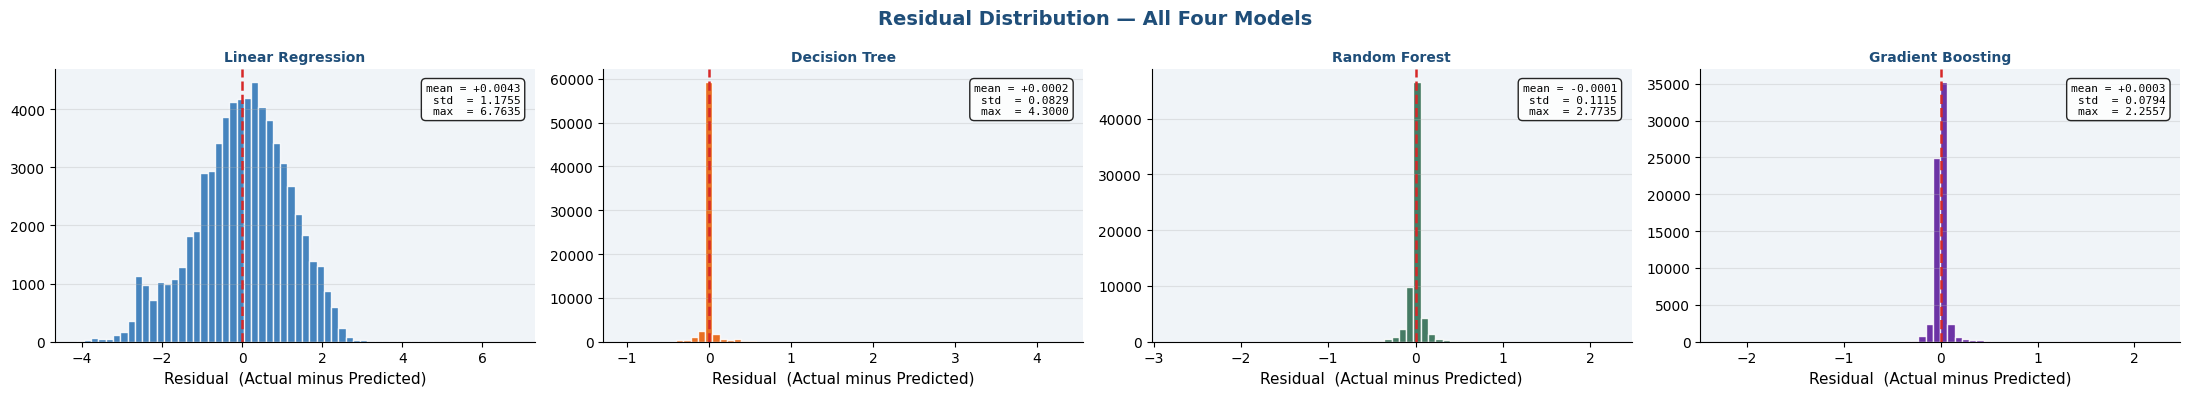

  Saved → output_figures/fig16_cv_boxplot.png


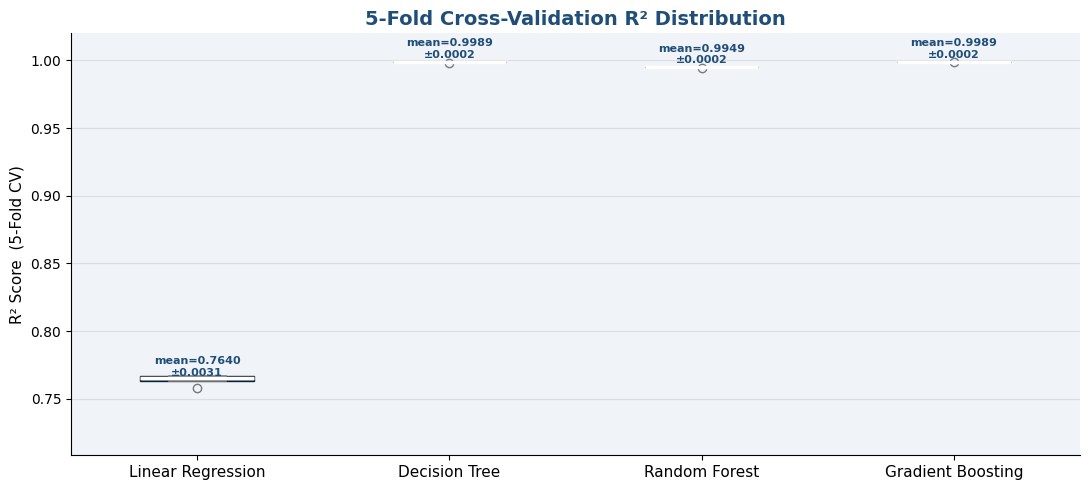


All 16 figures saved to output_figures/


In [12]:
# ── Figure 15: Residual distribution for all 4 models ───────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for ax, (name, pred), color, label in zip(axes, preds_dict.items(), MODEL_COLORS, labels):
    residuals = y_test - pred   # positive = we under-predicted; negative = over-predicted

    ax.hist(residuals, bins=60, color=color, edgecolor="white", alpha=0.88)
    ax.axvline(0, color=RED, lw=1.8, linestyle="--", label="Zero error")
    ax.set_title(label, fontsize=10, color=DARK)
    ax.set_xlabel("Residual  (Actual minus Predicted)")
    ax.grid(axis="y", alpha=0.3)

    # annotate with the mean, standard deviation and max absolute error
    stats_txt = (f"mean = {residuals.mean():+.4f}\n"
                 f"std  = {residuals.std():.4f}\n"
                 f"max  = {np.abs(residuals).max():.4f}")
    ax.text(0.97, 0.95, stats_txt,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85))

fig.suptitle("Residual Distribution — All Four Models",
             fontsize=14, fontweight="bold", color=DARK)
plt.tight_layout()
save_and_show("fig15_residuals.png")

# ── Figure 16: 5-Fold Cross-Validation boxplot ──────────────────────────────
cv_data = [cv_results[n] for n in results_df.index]

fig, ax = plt.subplots(figsize=(11, 5))

# create the boxplot with a different colour for each model
bp = ax.boxplot(cv_data, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2.5), widths=0.45)

for patch, color in zip(bp["boxes"], MODEL_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.85)
for w in bp["whiskers"]: w.set(color="grey", linewidth=1.2)
for c in bp["caps"]:     c.set(color="grey", linewidth=1.2)
for f in bp["fliers"]:   f.set(marker="o",   color="grey", alpha=0.5)

ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel(f"R² Score  ({CV_FOLDS}-Fold CV)")
ax.set_title(f"{CV_FOLDS}-Fold Cross-Validation R² Distribution", color=DARK, fontsize=14)
ax.set_ylim(max(0.70, min(cv_results[list(cv_results.keys())[0]]) - 0.05), 1.02)
ax.grid(axis="y", alpha=0.3)

# label each box with its mean and standard deviation
for i, cv in enumerate(cv_data):
    ax.text(i + 1, np.mean(cv) + 0.003,
            f"mean={np.mean(cv):.4f}\n±{np.std(cv):.4f}",
            ha="center", fontsize=8, fontweight="bold", color=DARK)

plt.tight_layout()
save_and_show("fig16_cv_boxplot.png")

print("\nAll 16 figures saved to output_figures/")

---
## 💾 Cell 13 — Save All Trained Models

Now that we've trained all four models, we save them to disk as `.pkl` files using **joblib**. This is important because:

- **No retraining needed:** The Random Forest took over a minute to train. Once saved, you can load it instantly in any future session.
- **Deployment ready:** These files can be loaded into a web application (e.g. FastAPI) to predict CVSS scores for new CVEs in real time.
- **Reproducibility:** The saved model is the exact state after training — frozen forever.

We also write a `model_metadata.json` file that records everything about how the models were trained — what features were used, what the metrics were, and when they were trained. This is good practice for any serious ML project.

> **Loading a saved model later is simple:**
> ```python
> import joblib
> model = joblib.load("saved_models/model_gradient_boosting.pkl")
> predicted_cvss = model.predict(X_new)
> ```

In [13]:
# map each model's internal name to a clean filename
file_map = {
    "Linear\nRegression" : "model_linear_regression.pkl",
    "Decision\nTree"     : "model_decision_tree.pkl",
    "Random\nForest"     : "model_random_forest.pkl",
    "Gradient\nBoosting" : "model_gradient_boosting.pkl",
}

# metadata dictionary — records everything about the training run
metadata = {
    "saved_at"        : datetime.datetime.now().isoformat(),
    "dataset"         : DATASET_PATH,
    "target_variable" : TARGET,
    "features_used"   : FEATURES,
    "n_features"      : len(FEATURES),
    "test_size"       : TEST_SIZE,
    "random_state"    : RANDOM_STATE,
    "cv_folds"        : CV_FOLDS,
    "models"          : {}
}

print("Saving trained models...\n")

for name, model in models_dict.items():
    label    = name.replace("\n", " ")
    filename = file_map[name]
    filepath = os.path.join(MODELS_DIR, filename)

    # compress=3 gives a good balance between file size and load speed
    joblib.dump(model, filepath, compress=3)

    size_kb = os.path.getsize(filepath) / 1024
    print(f"  Saved  {label:<25} ->  {filepath}  ({size_kb:.0f} KB)")

    # record the metrics for this model in the metadata
    metadata["models"][label] = {
        "file" : filename,
        "MAE"  : round(float(results_df.loc[name, "MAE"]),  4),
        "RMSE" : round(float(results_df.loc[name, "RMSE"]), 4),
        "R2"   : round(float(results_df.loc[name, "R²"]),   4),
    }

# save the metadata JSON file
meta_path = os.path.join(MODELS_DIR, "model_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=4)
print(f"\n  Saved  metadata              ->  {meta_path}")

print("\n" + "─" * 55)
print("How to reload a saved model in any future session:")
print("─" * 55)
print("  import joblib")
print(f"  model = joblib.load('{MODELS_DIR}/model_gradient_boosting.pkl')")
print(f"  predictions = model.predict(X_new)   # X_new shape: (n, {len(FEATURES)})")

Saving trained models...

  Saved  Linear Regression         ->  saved_models/model_linear_regression.pkl  (1 KB)
  Saved  Decision Tree             ->  saved_models/model_decision_tree.pkl  (10 KB)
  Saved  Random Forest             ->  saved_models/model_random_forest.pkl  (83661 KB)
  Saved  Gradient Boosting         ->  saved_models/model_gradient_boosting.pkl  (126 KB)

  Saved  metadata              ->  saved_models/model_metadata.json

───────────────────────────────────────────────────────
How to reload a saved model in any future session:
───────────────────────────────────────────────────────
  import joblib
  model = joblib.load('saved_models/model_gradient_boosting.pkl')
  predictions = model.predict(X_new)   # X_new shape: (n, 13)


---
## 🏆 Cell 14 — Final Summary Report

The last cell prints a clean, formatted summary of everything we did — the final performance table with all metrics, the best model on each metric, and a complete list of all output files created.

**Reading the results table:**
- **MAE** (↓ lower is better) — average error in CVSS score units. MAE=0.033 means on average we're only 0.033 CVSS points off.
- **RMSE** (↓ lower is better) — like MAE but punishes large errors more heavily.
- **R²** (↑ higher is better) — 0.9989 means the model explains 99.89% of the variation in CVSS scores.
- **CV R²** — the cross-validated R² (mean ± std across 5 folds) — confirms the model isn't just memorising the training data.

> **Bottom line: Gradient Boosting wins on R², RMSE, and CV stability. Decision Tree wins on MAE. Both are operationally excellent — Linear Regression is the only model that falls short for real-world use.**

In [14]:
# build the final summary table with CV stats added in
summary = results_df.copy()
summary["CV R² mean"] = [cv_results[n].mean() for n in results_df.index]
summary["CV R² std"]  = [cv_results[n].std()  for n in results_df.index]
summary.index = labels

print("=" * 78)
print("  FINAL RESULTS — NVD CYBERSECURITY CVSS PREDICTION")
print(f"  Dataset: {DATASET_PATH}  |  {len(df):,} records  |  80/20 split")
print("=" * 78)

print(f"\n  {'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}   {'CV R² mean':>12}   {'CV R² std':>10}")
print("  " + "─" * 72)

for m in labels:
    row = summary.loc[m]
    # put a star next to the best model on test R²
    star = " <-- BEST" if row["R²"] == summary["R²"].max() else ""
    print(f"  {m:<25} {row['MAE']:>8.4f} {row['RMSE']:>8.4f} {row['R²']:>8.4f} "
          f"  {row['CV R² mean']:>12.4f}   {row['CV R² std']:>10.4f}{star}")

print("  " + "─" * 72)

# call out the winner on each metric
print("\n  Best model by metric:")
print(f"    MAE  (lowest)  : {summary['MAE'].idxmin():<25}  {summary['MAE'].min():.4f}")
print(f"    RMSE (lowest)  : {summary['RMSE'].idxmin():<25}  {summary['RMSE'].min():.4f}")
print(f"    R²   (highest) : {summary['R²'].idxmax():<25}  {summary['R²'].max():.4f}")
print(f"    CV   (highest) : {summary['CV R² mean'].idxmax():<25}  {summary['CV R² mean'].max():.4f}")

print("\n  Output files created:")
fig_files   = sorted(os.listdir(OUTPUT_DIR))
model_files = sorted(os.listdir(MODELS_DIR))
print(f"    output_figures/  ({len(fig_files)} files):   {', '.join(fig_files[:4])} ...")
print(f"    saved_models/    ({len(model_files)} files):   {', '.join(model_files)}")

print("\n" + "=" * 78)
print("  PIPELINE COMPLETE")
print("=" * 78)

  FINAL RESULTS — NVD CYBERSECURITY CVSS PREDICTION
  Dataset: NVD_Cybersecurity_Dataset.csv  |  337,705 records  |  80/20 split

  Model                          MAE     RMSE       R²     CV R² mean    CV R² std
  ────────────────────────────────────────────────────────────────────────
  Linear Regression           0.9332   1.1755   0.7634         0.7640       0.0031
  Decision Tree               0.0287   0.0829   0.9988         0.9989       0.0002
  Random Forest               0.0505   0.1115   0.9979         0.9949       0.0002
  Gradient Boosting           0.0332   0.0794   0.9989         0.9989       0.0002 <-- BEST
  ────────────────────────────────────────────────────────────────────────

  Best model by metric:
    MAE  (lowest)  : Decision Tree              0.0287
    RMSE (lowest)  : Gradient Boosting          0.0794
    R²   (highest) : Gradient Boosting          0.9989
    CV   (highest) : Gradient Boosting          0.9989

  Output files created:
    output_figures/  (16 f